In [61]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

k1 = 0.05    
k2 = 0.0255  
k3 = 0.15    
CA0 = 2.1    


### Периодический реактор


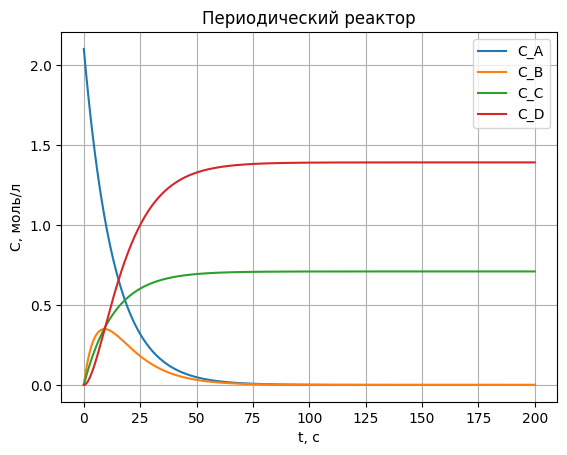

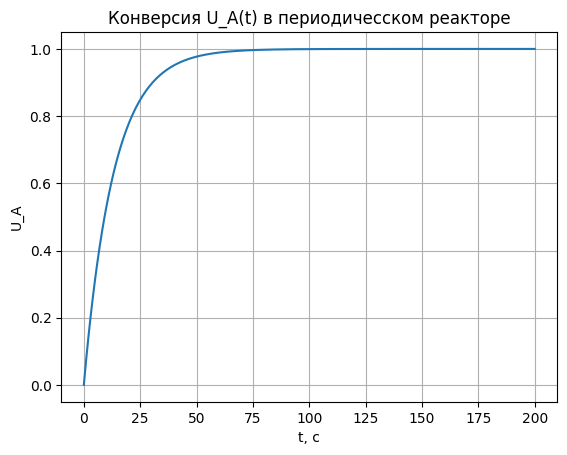

Конверсия 80% при t = 21.553884711779446 с


C:\Users\dasha\AppData\Local\Temp\ipykernel_6184\3079512142.py:51: RuntimeWarning: invalid value encountered in divide
  SB_batch = CB_batch / (CA0 - CA_batch) #селективность


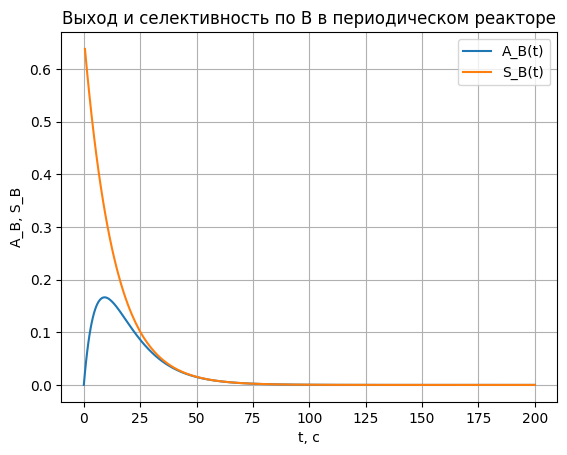

In [62]:
def rhs_batch(t, C):
    CA, CB, CC, CD = C
    rA = -(k1 + k2) * CA
    rB = k1 * CA - k3 * CB
    rC = k2 * CA
    rD = k3 * CB
    return [rA, rB, rC, rD]

#Зависимость концентраций от времени
t_span = (0.0, 200.0) #интервал времени
t_eval = np.linspace(*t_span, 400) #массив значений t
C0 = [CA0, 0.0, 0.0, 0.0] #начальные условия

sol_batch = solve_ivp(rhs_batch, t_span, C0, t_eval=t_eval) #решание ОДУ

plt.figure() 
plt.plot(sol_batch.t, sol_batch.y[0], label='C_A')
plt.plot(sol_batch.t, sol_batch.y[1], label='C_B')
plt.plot(sol_batch.t, sol_batch.y[2], label='C_C')
plt.plot(sol_batch.t, sol_batch.y[3], label='C_D')
plt.xlabel('t, с')
plt.ylabel('C, моль/л')
plt.title('Периодический реактор')
plt.legend()
plt.grid(True)
plt.show()

#Конверсия
CA_batch = sol_batch.y[0] #концентрация A
UA_batch = (CA0 - CA_batch) / CA0 #конверсия

plt.figure()
plt.plot(sol_batch.t, UA_batch)
plt.xlabel('t, с')
plt.ylabel('U_A')
plt.title('Конверсия U_A(t) в периодичесском реакторе')
plt.grid(True)
plt.show()

#Вычисление параметров для конверсии 80%
t_arr = sol_batch.t 
UA_target = 0.8
idx = np.argmin(np.abs(UA_batch - UA_target)) #точка, в которой модуль отклонения конверсии от 80% минимален
t_star = t_arr[idx]

print("Конверсия 80% при t =", t_star, "с")

#Выход и селективность по B
CB_batch = sol_batch.y[1]
AB_batch = CB_batch / CA0 #выход
SB_batch = CB_batch / (CA0 - CA_batch) #селективность

plt.figure()
plt.plot(t_arr, AB_batch, label='A_B(t)')
plt.plot(t_arr, SB_batch, label='S_B(t)')
plt.xlabel('t, с')
plt.ylabel('A_B, S_B')
plt.title('Выход и селективность по B в периодическом реакторе')
plt.legend()
plt.grid(True)
plt.show()


Оптимальное время реакции: 9.21522470264973 с
Конечная конверсия U_A: 0.5012992668231
Конечный выход A_B: 0.16623304868549513


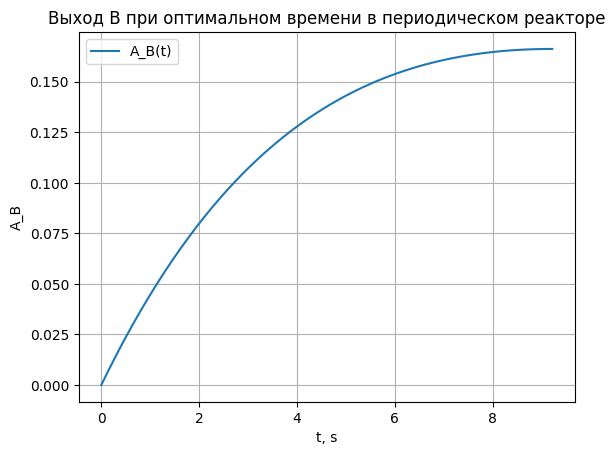

In [63]:
#Функция цели
def objective_batch(t_end):
    t_span = (0.0, t_end)
    t_eval = np.linspace(0.0, t_end, 400)
    C0 = [CA0, 0.0, 0.0, 0.0]
    sol = solve_ivp(rhs_batch, t_span, C0, t_eval=t_eval) #решение ОДУ
    CB = sol.y[1]
    AB = CB / CA0 #выход
    if AB.max() > AB[-1]: #проверка выхода на максимум
        penalty = AB.max() - AB[-1] #штраф
    else:
        penalty = 0.0
    return -AB[-1] + penalty

res = minimize_scalar(objective_batch, bounds=(1e-3, 300.0)) #ищет t_end при котором objective_batch минимальна
t_opt = res.x
print("Оптимальное время реакции:", t_opt, "с")

t_span_opt = (0.0, t_opt)
t_eval_opt = np.linspace(0.0, t_opt, 400)
C0 = [CA0, 0.0, 0.0, 0.0]
sol_opt = solve_ivp(rhs_batch, t_span_opt, C0, t_eval=t_eval_opt)

t_arr = sol_opt.t
CA_opt = sol_opt.y[0]
CB_opt = sol_opt.y[1]

UA_opt = (CA0 - CA_opt) / CA0 #конверсия
AB_opt = CB_opt / CA0 #выход

print("Конечная конверсия U_A:", UA_opt[-1])
print("Конечный выход A_B:", AB_opt[-1])

plt.figure()
plt.plot(t_arr, AB_opt, label='A_B(t)')
plt.xlabel('t, s')
plt.ylabel('A_B')
plt.title('Выход B при оптимальном времени в периодическом реакторе')
plt.grid(True)
plt.legend()
plt.show()


### Реактор идеального смешения непрерывного действия

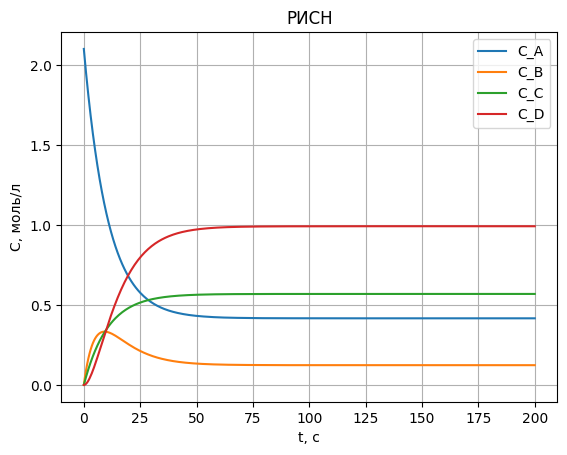

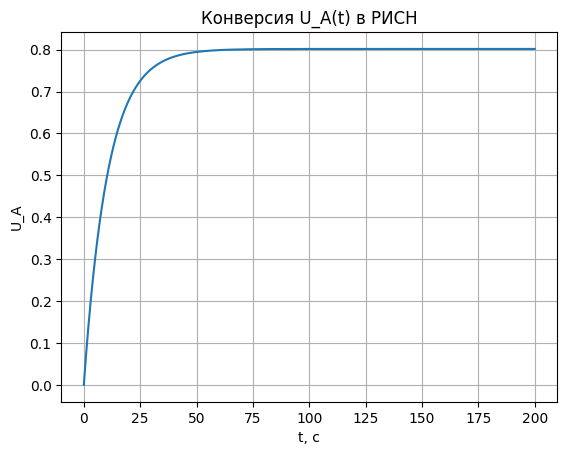

Стационарная U_A = 0.8017698975774766 при V = 3 и v = 0.056


C:\Users\dasha\AppData\Local\Temp\ipykernel_6184\2814356577.py:57: RuntimeWarning: invalid value encountered in divide
  SB_cstr = CB_cstr / (CA0 - CA_cstr)


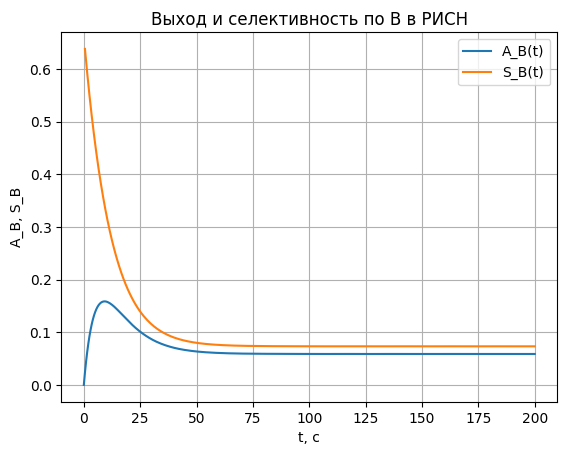

In [ ]:
V = 3 #объем
v = 0.056 #объемный расход w
tau = V / v 

def rhs_cstr(t, C):
    CA, CB, CC, CD = C
    rA = -(k1 + k2) * CA
    rB = k1 * CA - k3 * CB
    rC = k2 * CA
    rD = k3 * CB
    dCA = (CA0 - CA)/tau + rA
    dCB = (0.0  - CB)/tau + rB
    dCC = (0.0  - CC)/tau + rC
    dCD = (0.0  - CD)/tau + rD
    return [dCA, dCB, dCC, dCD]

#Зависимость концентраций от времени
t_span_cstr = (0.0, 200)
t_eval_cstr = np.linspace(*t_span_cstr, 400)
C0_cstr = [CA0, 0.0, 0.0, 0.0]

sol_cstr = solve_ivp(rhs_cstr, t_span_cstr, C0_cstr, t_eval=t_eval_cstr)

plt.figure()
plt.plot(sol_cstr.t, sol_cstr.y[0], label='C_A')
plt.plot(sol_cstr.t, sol_cstr.y[1], label='C_B')
plt.plot(sol_cstr.t, sol_cstr.y[2], label='C_C')
plt.plot(sol_cstr.t, sol_cstr.y[3], label='C_D')
plt.xlabel('t, с')
plt.ylabel('C, моль/л')
plt.title('РИСН')
plt.legend()
plt.grid(True)
plt.show()

#Конверсия
CA_cstr = sol_cstr.y[0]
UA_cstr = (CA0 - CA_cstr) / CA0

plt.figure()
plt.plot(sol_cstr.t, UA_cstr)
plt.xlabel('t, с')
plt.ylabel('U_A')
plt.title('Конверсия U_A(t) в РИСН')
plt.grid(True)
plt.show()

#Вычсление параметров для конверсии 80%
UA_ss = UA_cstr[-1] #последняя точка конверсии

print("Стационарная U_A =", UA_ss, "при V =", V, "и w =", v)

#Выход и селективность по B
t_cstr = sol_cstr.t
CB_cstr = sol_cstr.y[1]
AB_cstr = CB_cstr / CA0
SB_cstr = CB_cstr / (CA0 - CA_cstr)

plt.figure()
plt.plot(t_cstr, AB_cstr, label='A_B(t)')
plt.plot(t_cstr, SB_cstr, label='S_B(t)')
plt.xlabel('t, с')
plt.ylabel('A_B, S_B')
plt.title('Выход и селективность по B в РИСН')
plt.legend()
plt.grid(True)
plt.show()


Оптимальное время пребывания: 3.218224964074777 с
Стационарная конверсия U_A = 0.19547204170666374
Стационарный выход A_B = 0.08729836380465686


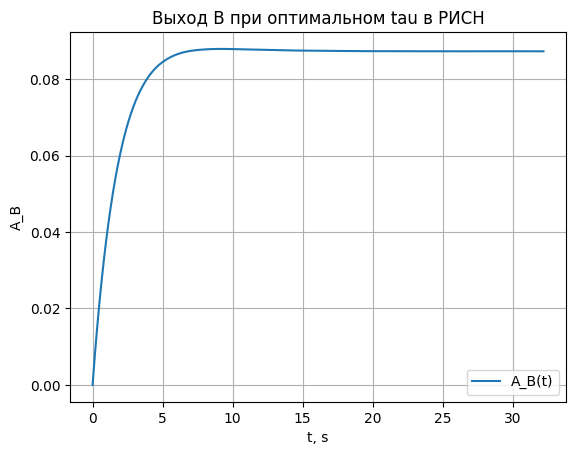

Объём реактора при оптимальном режиме: 0.18022059798818751 м^3


In [65]:
def rhs_cstr(t, C, tau):
    CA, CB, CC, CD = C
    rA = -(k1 + k2) * CA
    rB = k1 * CA - k3 * CB
    rC = k2 * CA
    rD = k3 * CB
    dCA = (CA0 - CA)/tau + rA
    dCB = (0.0  - CB)/tau + rB
    dCC = (0.0  - CC)/tau + rC
    dCD = (0.0  - CD)/tau + rD
    return [dCA, dCB, dCC, dCD]

#Поиск оптимальных времени и концентрации при известном тау
def solve_cstr_for_tau(tau):
    t_span = (0.0, 10*tau)
    t_eval = np.linspace(*t_span, 400)
    C0 = [CA0, 0.0, 0.0, 0.0]
    sol = solve_ivp(lambda t, C: rhs_cstr(t, C, tau), 
                    t_span, C0, t_eval=t_eval) #фиксирует тау и дает функцию двух переменных
    return sol

#Поиск тау
def objective_cstr(tau):
    sol = solve_cstr_for_tau(tau)
    CB = sol.y[1]
    AB = CB / CA0 #выход
    AB_out = AB[-1]
    penalty = 0.0
    if AB.max() > AB_out:
        penalty = 15 * (AB.max() - AB_out) #штраф
    return -AB_out + penalty

res = minimize_scalar(objective_cstr, bounds=(1e-2, 500.0))
tau_opt = res.x
print("Оптимальное время пребывания:", tau_opt, "с")

sol_opt = solve_cstr_for_tau(tau_opt)
t_arr = sol_opt.t
CA_opt = sol_opt.y[0]
CB_opt = sol_opt.y[1]
UA_opt = (CA0 - CA_opt) / CA0
AB_opt = CB_opt / CA0

print("Стационарная конверсия U_A =", UA_opt[-1])
print("Стационарный выход A_B =", AB_opt[-1])

plt.figure()
plt.plot(t_arr, AB_opt, label='A_B(t)')
plt.xlabel('t, s')
plt.ylabel('A_B')
plt.title('Выход B при оптимальном tau в РИСН')
plt.grid(True)
plt.legend()
plt.show()

V_cstr = v * tau_opt   
print("Объём реактора при оптимальном режиме:", V_cstr, "м^3")

### Трубчатый реактор

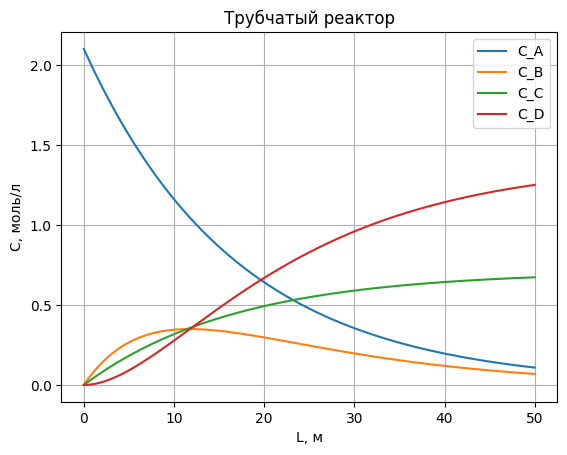

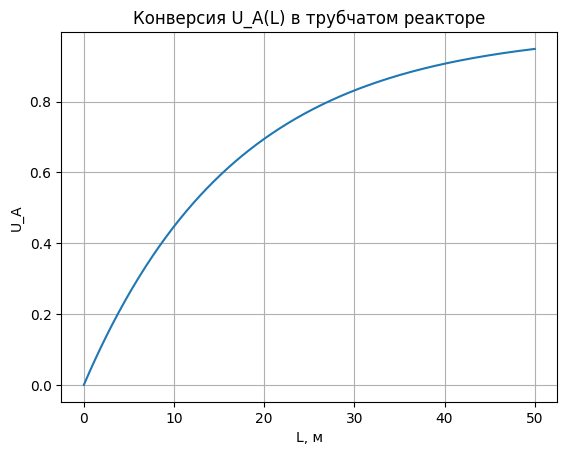

L = 27.19298245614035 м


C:\Users\dasha\AppData\Local\Temp\ipykernel_6184\1266054370.py:62: RuntimeWarning: invalid value encountered in divide
  SB_pfr = CB_pfr / (CA0 - CA_pfr)


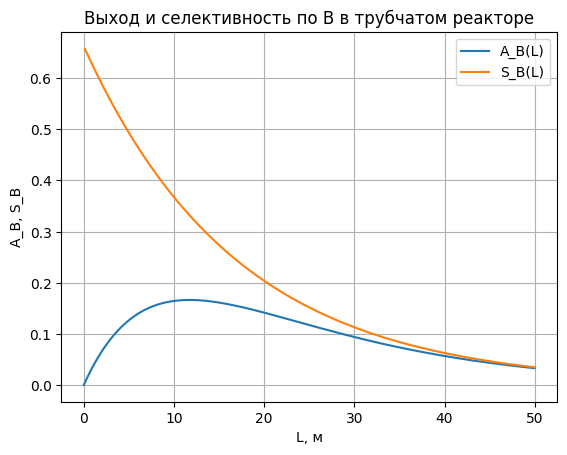

In [66]:
d = 0.1 
L = 50.0 
Q = 0.01  # = v
S = np.pi * d**2 / 4
w = Q / S

def rhs_pfr(L_coord, C):
    CA, CB, CC, CD = C
    rA = -(k1 + k2) * CA
    rB = k1 * CA - k3 * CB
    rC = k2 * CA
    rD = k3 * CB
    dCA_dL = rA / w
    dCB_dL = rB / w
    dCC_dL = rC / w
    dCD_dL = rD / w
    return [dCA_dL, dCB_dL, dCC_dL, dCD_dL]

#Зависимость концентрации от длины
L_span = (0.0, L)
L_eval = np.linspace(*L_span, 400)
C0_pfr = [CA0, 0.0, 0.0, 0.0]

sol_pfr = solve_ivp(rhs_pfr, L_span, C0_pfr, t_eval=L_eval)

plt.figure()
plt.plot(sol_pfr.t, sol_pfr.y[0], label='C_A')
plt.plot(sol_pfr.t, sol_pfr.y[1], label='C_B')
plt.plot(sol_pfr.t, sol_pfr.y[2], label='C_C')
plt.plot(sol_pfr.t, sol_pfr.y[3], label='C_D')
plt.xlabel('L, м')
plt.ylabel('C, моль/л')
plt.title('Трубчатый реактор')
plt.legend()
plt.grid(True)
plt.show()

#Конверсия
CA_pfr = sol_pfr.y[0]
UA_pfr = (CA0 - CA_pfr) / CA0

plt.figure()
plt.plot(sol_pfr.t, UA_pfr)
plt.xlabel('L, м')
plt.ylabel('U_A')
plt.title('Конверсия U_A(L) в трубчатом реакторе')
plt.grid(True)
plt.show()

#Вычсление параметров для конверсии 80%
L_arr = sol_pfr.t
UA_pfr = (CA0 - CA_pfr) / CA0
UA_target = 0.8
idx_L = np.argmin(np.abs(UA_pfr - UA_target))
L_star = L_arr[idx_L]

print("L =", L_star, "м")

#Выход и селективность по B
CB_pfr = sol_pfr.y[1]
AB_pfr = CB_pfr / CA0
SB_pfr = CB_pfr / (CA0 - CA_pfr)

plt.figure()
plt.plot(L_arr, AB_pfr, label='A_B(L)')
plt.plot(L_arr, SB_pfr, label='S_B(L)')
plt.xlabel('L, м')
plt.ylabel('A_B, S_B')
plt.title('Выход и селективность по B в трубчатом реакторе')
plt.legend()
plt.grid(True)
plt.show()


Оптимальная длина трубы L_opt = 11.7331895228367 м
Конверсия U_A = 0.5012992969212915
Выход A_B = 0.16623304868549477


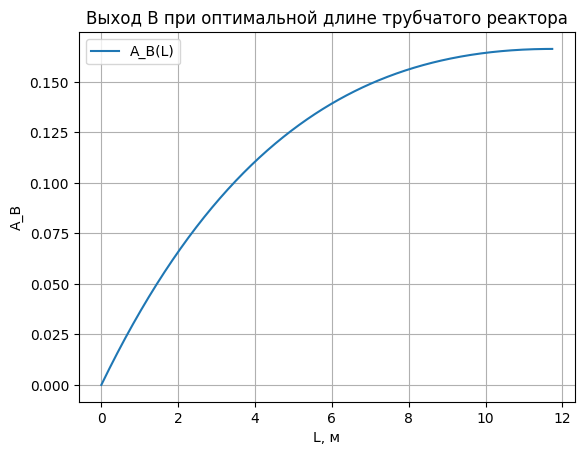

Объём реактора при оптимальной длине: 0.09215225502030128 м^3


In [67]:
def solve_pfr_for_L(L_end):
    L_span = (0.0, L_end)
    L_eval = np.linspace(*L_span, 400)
    C0_pfr = [CA0, 0.0, 0.0, 0.0]
    sol = solve_ivp(rhs_pfr, L_span, C0_pfr, t_eval=L_eval)
    return sol

def objective_pfr(L_end):
    sol = solve_pfr_for_L(L_end)
    CB = sol.y[1]
    AB = CB / CA0 #выход
    AB_out = AB[-1]
    penalty = 0.0
    if AB.max() > AB_out + 1e-3:
        penalty = AB.max() - AB_out
    return -AB_out + penalty

res_L = minimize_scalar(objective_pfr, bounds=(0.1, 200.0))
L_opt = res_L.x
print("Оптимальная длина трубы L_opt =", L_opt, "м")

sol_pfr_opt = solve_pfr_for_L(L_opt)
L_arr = sol_pfr_opt.t
CA_opt = sol_pfr_opt.y[0]
CB_opt = sol_pfr_opt.y[1]
UA_opt = (CA0 - CA_opt) / CA0 #конверсия
AB_opt = CB_opt / CA0 #выход

print("Конверсия U_A =", UA_opt[-1])
print("Выход A_B =", AB_opt[-1])

plt.figure()
plt.plot(L_arr, AB_opt, label='A_B(L)')
plt.xlabel('L, м')
plt.ylabel('A_B')
plt.title('Выход B при оптимальной длине трубчатого реактора')
plt.grid(True)
plt.legend()
plt.show()

S_pfr = np.pi * d**2 / 4
V_pfr = S_pfr * L_opt
print("Объём реактора при оптимальной длине:", V_pfr, "м^3")
